|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Build a GPT<h1>|
|<h2>Lecture:</h2>|<h1><b>The Transformer block (code)<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

import torch
import torch.nn as nn
import torch.nn.functional as F

# vector plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Demo of linear separation after dimensionality expansion

C:\Users\marco\AppData\Local\Temp\ipykernel_4452\2396038546.py:36: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


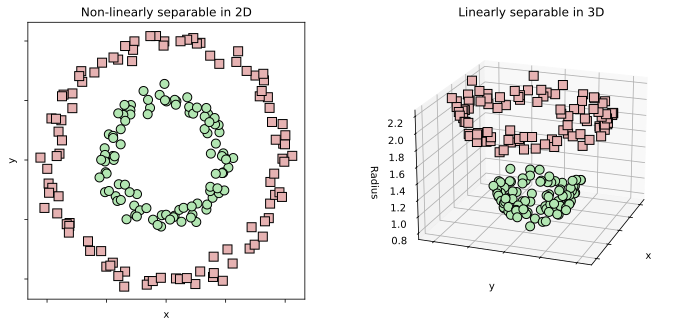

In [2]:
# angles
n = 100
theta = np.linspace(0,2*np.pi-1/n,n)

# coordinates in 2D
x_inner = 1*np.cos(theta) + np.random.randn(n)/10
y_inner = 1*np.sin(theta) + np.random.randn(n)/10
x_outer = 2*np.cos(theta) + np.random.randn(n)/10
y_outer = 2*np.sin(theta) + np.random.randn(n)/10

# dimensionality-expansion via nonlinear transform
z_inner = np.sqrt(x_inner**2 + y_inner**2)
z_outer = np.sqrt(x_outer**2 + y_outer**2)



### 2D scatter plot
fig = plt.figure(figsize=(12,5))
ax0 = fig.add_subplot(121)

ax0.plot(x_inner,y_inner,'ko',markerfacecolor=[.7,.9,.7],markersize=9)
ax0.plot(x_outer,y_outer,'ks',markerfacecolor=[.9,.7,.7],markersize=9)
ax0.axis('square')
ax0.set(title='Non-linearly separable in 2D',xlabel='x',ylabel='y',
        xticklabels=[],yticklabels=[])

### 3D scatter plot
ax1 = fig.add_subplot(122, projection='3d')
ax1.plot(x_inner,y_inner,z_inner,'ko',markerfacecolor=[.7,.9,.7],markersize=9)
ax1.plot(x_outer,y_outer,z_outer,'ks',markerfacecolor=[.9,.7,.7],markersize=9)
ax1.set(title='Linearly separable in 3D',xlabel='x',ylabel='y',zlabel='Radius',
        xticklabels=[],yticklabels=[])
ax1.view_init(20,20)


plt.tight_layout()
plt.show()

# And now to the main part of the code :)

# Model hyperparameters

In [3]:
# data hyperparameters
seq_len = 8

# model hyperparameters
embed_dim = 128

# training hyperparameters
batch_size = 5

# One attention head

In [4]:
# create one attention head
class OneAttentionHead(nn.Module):
  def __init__(self,embed_dim):
    super().__init__()

    # create the k/q/v matrices
    self.key   = nn.Linear(embed_dim,embed_dim,bias=False)
    self.query = nn.Linear(embed_dim,embed_dim,bias=False)
    self.value = nn.Linear(embed_dim,embed_dim,bias=False)
    self.W0    = nn.Linear(embed_dim,embed_dim,bias=False)

  def forward(self,x):

    # run the token embeddings vectors through attention
    k = self.key(x)
    q = self.query(x)
    v = self.value(x)
    y = F.scaled_dot_product_attention(q,k,v,is_causal=True)
    y = self.W0(y) # linear weightings post-attention

    return y

In [5]:
# explore the attention head
onehead = OneAttentionHead(embed_dim)

print(onehead)

# run some fake data through
tokenEmbeds = torch.randn(batch_size, seq_len, embed_dim)
out = onehead(tokenEmbeds)
print(f'\nOutput ({out.shape}): \n{out}')

OneAttentionHead(
  (key): Linear(in_features=128, out_features=128, bias=False)
  (query): Linear(in_features=128, out_features=128, bias=False)
  (value): Linear(in_features=128, out_features=128, bias=False)
  (W0): Linear(in_features=128, out_features=128, bias=False)
)

Output (torch.Size([5, 8, 128])): 
tensor([[[-0.0370, -0.1263,  0.0920,  ..., -0.1930,  0.2746,  0.2363],
         [-0.1553,  0.0914, -0.3362,  ..., -0.3097, -0.0294,  0.2033],
         [-0.1070, -0.1108, -0.0519,  ..., -0.3269,  0.1770,  0.1732],
         ...,
         [ 0.1246, -0.1496, -0.0499,  ..., -0.2050,  0.0058,  0.1832],
         [ 0.0751, -0.0530, -0.0050,  ..., -0.1124, -0.0242,  0.0819],
         [ 0.1112, -0.0517, -0.0271,  ..., -0.1641,  0.0185,  0.0945]],

        [[ 0.1592,  0.5059, -0.0243,  ...,  0.2503, -0.0548, -0.3283],
         [ 0.0479,  0.0986,  0.1070,  ...,  0.2105, -0.1331, -0.2904],
         [-0.0066, -0.1126,  0.0112,  ...,  0.1275, -0.1160, -0.0706],
         ...,
         [ 0.0804,  

# Transformer block

In [6]:
#
class TransformerBlock(nn.Module):
  def __init__(self,embed_dim):
    super().__init__()

    # attention sublayer
    self.layerNormAttn = nn.LayerNorm(embed_dim)
    self.attn = OneAttentionHead(embed_dim)

    # feedforward (MLP) sublayer
    self.layerNormMLP  = nn.LayerNorm(embed_dim)
    self.W1   = nn.Linear(embed_dim,4*embed_dim) # 4x expansion
    self.gelu = nn.GELU()                        # nonlinearity
    self.W2   = nn.Linear(4*embed_dim,embed_dim) # 4x contraction


  def forward(self,x):

    ## --- attention sublayer --- ##
    # save a copy of pre-attention data
    residual = x

    # layernorm -> attention
    h        = self.layerNormAttn(x)
    attn_out = self.attn(h)

    # combine pre-attention copy + attention adjustments
    x        = residual + attn_out

    # note: could do this in one line:
    #x = x + self.attn(self.layerNormAttn(x))
    ## -------------------------- ##



    ## ------ MLP sublayer ------ ##
    # copy of pre-MLP data
    residual2 = x

    # layernorm before MLP
    h2        = self.layerNormMLP(x)

    # expansion-nonlinearity-contraction
    mlp_out   = self.W2(self.gelu(self.W1(h2)))

    # combine pre-MLP copy + MLP-adjustment
    y         = residual2 + mlp_out
    ## -------------------------- ##


    return y

In [7]:
# create and explore an instance
transblock = TransformerBlock(embed_dim)
print(transblock)

TransformerBlock(
  (layerNormAttn): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (attn): OneAttentionHead(
    (key): Linear(in_features=128, out_features=128, bias=False)
    (query): Linear(in_features=128, out_features=128, bias=False)
    (value): Linear(in_features=128, out_features=128, bias=False)
    (W0): Linear(in_features=128, out_features=128, bias=False)
  )
  (layerNormMLP): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (W1): Linear(in_features=128, out_features=512, bias=True)
  (gelu): GELU(approximate='none')
  (W2): Linear(in_features=512, out_features=128, bias=True)
)


In [8]:
# again, pushing data through
out = transblock(tokenEmbeds)
print(f'\nOutput ({out.shape}): \n{out}')


Output (torch.Size([5, 8, 128])): 
tensor([[[-1.1337,  0.2619,  0.9631,  ...,  1.1324,  1.5468,  0.2223],
         [ 0.7131,  0.2760,  0.8754,  ..., -1.6149, -0.5629,  0.4392],
         [-0.3669, -1.3830,  0.6635,  ...,  0.2560, -1.3256,  1.6459],
         ...,
         [-0.3189,  2.2227,  0.0083,  ..., -0.0809,  3.4889,  0.6321],
         [ 1.1683,  1.4205, -0.6825,  ...,  1.8174,  0.2347,  0.9771],
         [-0.8223,  0.0824,  0.9316,  ..., -0.1769,  0.1644,  0.2644]],

        [[-1.6899,  0.8915,  1.2748,  ...,  0.4315, -0.0185,  1.3203],
         [-0.7469,  1.2679,  0.5439,  ...,  0.3941, -1.3384, -0.7010],
         [-0.4048, -0.2592, -1.7330,  ..., -0.6082, -1.8134, -1.4718],
         ...,
         [ 0.8129, -0.2888,  1.1510,  ..., -0.9142, -0.3910,  0.2578],
         [ 1.2681, -0.6085,  1.3738,  ..., -0.1389,  1.6688,  0.4942],
         [ 0.3190, -0.3704, -1.8588,  ..., -0.6537,  1.4433,  0.1696]],

        [[ 0.1968,  0.4520, -0.5804,  ...,  1.3253,  1.6825, -0.6540],
         